Paramètres (theta) : [[25.63636364]
 [ 2.5030303 ]]


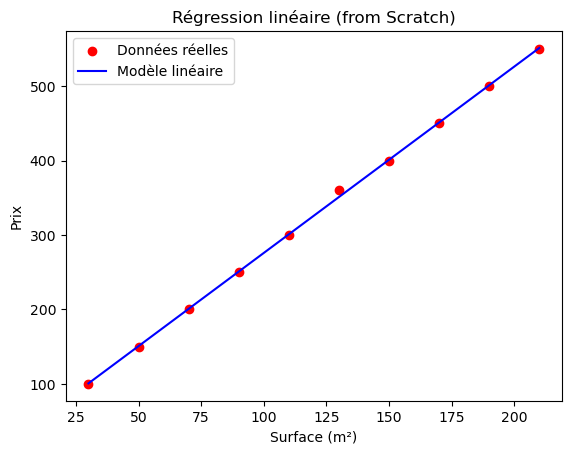

In [2]:
#Régression linéaire (from Scratch)
import numpy as np
import matplotlib.pyplot as plt


# ETAPE 1 : Création du dataset

# On définit un dataset représentant :
# - la surface d'un logement (en m²)
# - son prix (en milliers d'euros par exemple)

surface = np.array([[30],[50],[70],[90],[110],[130],[150],[170],[190],[210]])
prix = np.array([[100],[150],[200],[250],[300],[360],[400],[450],[500],[550]])


# ETAPE 2 : Préparation des données

# On ajoute une colonne de 1 pour représenter le biais (intercept)
# Cela permet d'utiliser la forme matricielle de la régression

X = np.c_[np.ones((len(surface),1)), surface]


# ETAPE 3 : Calcul des paramètres (theta)

# On applique l'équation normale :
# theta = (X^T X)^(-1) X^T y

theta = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(prix)

# Affichage des paramètres
print("Paramètres (theta) :", theta)


# ETAPE 4 : Prédictions

# On crée une série de valeurs de surface pour tracer la droite

surface_ligne = np.linspace(30, 210, 100).reshape(-1,1)

# On ajoute le biais à ces nouvelles données
X_ligne = np.c_[np.ones((100,1)), surface_ligne]

# Calcul des prix prédits
prix_pred = X_ligne.dot(theta)


# ETAPE 5 : Visualisation

# On affiche les données réelles et la droite de régression

plt.scatter(surface, prix, color='red', label='Données réelles')
plt.plot(surface_ligne, prix_pred, color='blue', label='Modèle linéaire')
plt.xlabel("Surface (m²)")
plt.ylabel("Prix")
plt.title("Régression linéaire (from Scratch)")
plt.legend()
plt.show()


Intercept : [25.63636364]
Coefficient : [[2.5030303]]


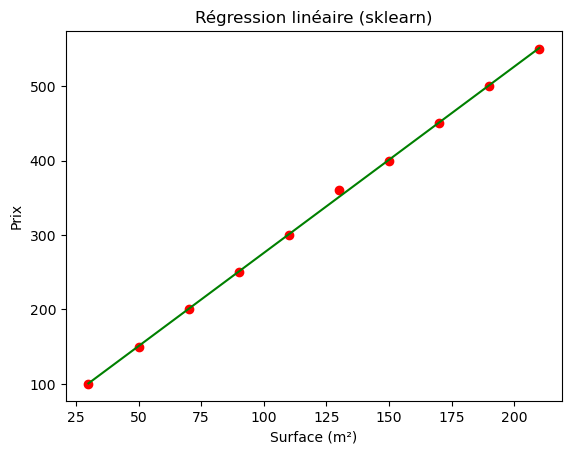

In [6]:
#Régression linéaire (sklearn)
from sklearn.linear_model import LinearRegression


# ETAPE 1 : Création du modèle

# LinearRegression permet de calculer automatiquement
# les paramètres du modèle

modele = LinearRegression()


# ETAPE 2 : Entraînement du modèle

# Le modèle apprend la relation entre surface et prix

modele.fit(surface, prix)

# ETAPE 3 : Prédictions

# On prédit les prix pour les surfaces générées

prix_pred = modele.predict(surface_ligne)

# Affichage des paramètres
print("Intercept :", modele.intercept_)
print("Coefficient :", modele.coef_)


# ETAPE 4 : Visualisation

plt.scatter(surface, prix, color='red')
plt.plot(surface_ligne, prix_pred, color='green')
plt.xlabel("Surface (m²)")
plt.ylabel("Prix")
plt.title("Régression linéaire (sklearn)")
plt.show()


Paramètres : [[24. ]
 [ 2.4]
 [ 4. ]]


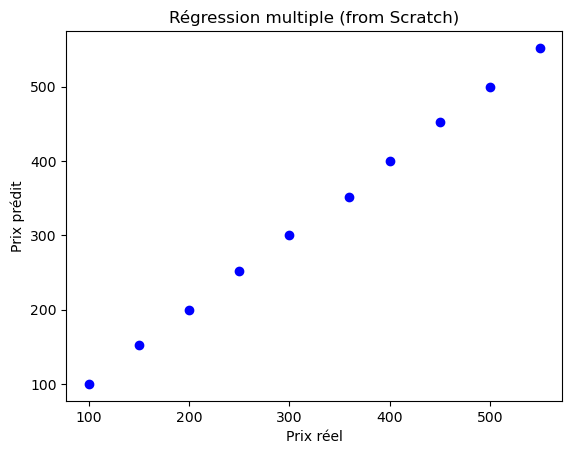

In [7]:
# Régression linéaire multiple from scratch

# ETAPE 1 : Ajout d'une deuxième variable

# On ajoute le nombre de chambres

chambres = np.array([[1],[2],[2],[3],[3],[4],[4],[5],[5],[6]])

# Construction du dataset avec deux variables
X_multi = np.c_[surface, chambres]

# ETAPE 2 : Ajout du biais

X = np.c_[np.ones((len(X_multi),1)), X_multi]


# ETAPE 3 : Calcul des paramètres

theta_multi = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(prix)

print("Paramètres :", theta_multi)


# ETAPE 4 : Prédictions

prix_pred_multi = X.dot(theta_multi)


# ETAPE 5 : Visualisation

# Comparaison entre valeurs réelles et prédites

plt.scatter(prix, prix_pred_multi, color='blue')
plt.xlabel("Prix réel")
plt.ylabel("Prix prédit")
plt.title("Régression linéaire multiple (from Scratch)")
plt.show()

Intercept : [24.]
Coefficients : [[2.4 4. ]]


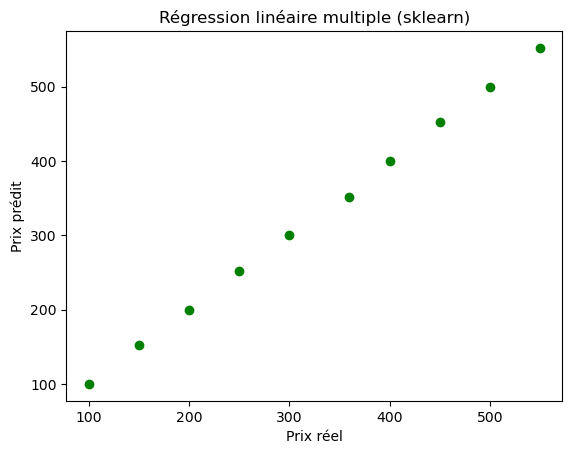

In [11]:
# Régression linéaire multiple (sklearn)

# ETAPE 1 : Création du modèle
modele = LinearRegression()


# ETAPE 2 : Entraînement
modele.fit(X_multi, prix)

# ETAPE 3 : Affichage des paramètres

print("Intercept :", modele.intercept_)
print("Coefficients :", modele.coef_)

# ETAPE 4 : Prédictions
prix_pred_multi = modele.predict(X_multi)

# ETAPE 5 : Visualisation
plt.scatter(prix, prix_pred_multi, color='green')
plt.xlabel("Prix réel")
plt.ylabel("Prix prédit")
plt.title("Régression linéaire multiple (sklearn)")
plt.show()

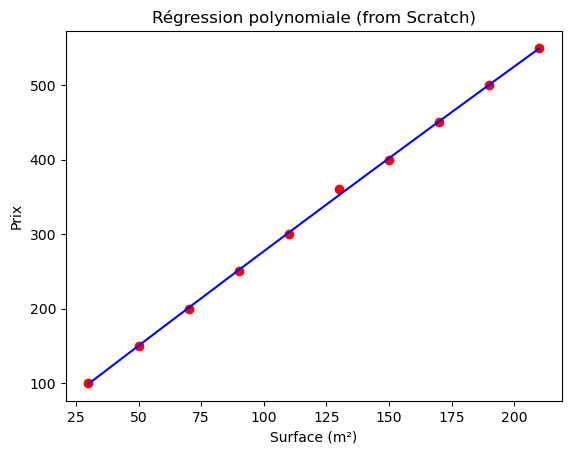

In [12]:
# Régression polynomiale (from Scratch)

# ETAPE 1 : Création des variables polynomiales

# On ajoute x² pour capturer une relation non linéaire

def variables_polynomiales(X, degre):
    X_poly = X
    for i in range(2, degre+1):
        X_poly = np.hstack((X_poly, X**i))
    return X_poly

X_poly = variables_polynomiales(surface, 2)

# ETAPE 2 : Ajout du biais

X_poly_b = np.c_[np.ones((len(surface),1)), X_poly]


# ETAPE 3 : Calcul des paramètres

theta_poly = np.linalg.inv(X_poly_b.T.dot(X_poly_b)).dot(X_poly_b.T).dot(prix)


# ETAPE 4 : Prédictions

surface_poly = variables_polynomiales(surface_ligne, 2)
X_poly_ligne = np.c_[np.ones((100,1)), surface_poly]

prix_poly_pred = X_poly_ligne.dot(theta_poly)


# ETAPE 5 : Visualisation

plt.scatter(surface, prix, color='red')
plt.plot(surface_ligne, prix_poly_pred, color='blue')
plt.xlabel("Surface (m²)")
plt.ylabel("Prix")
plt.title("Régression polynomiale (from Scratch)")
plt.show()


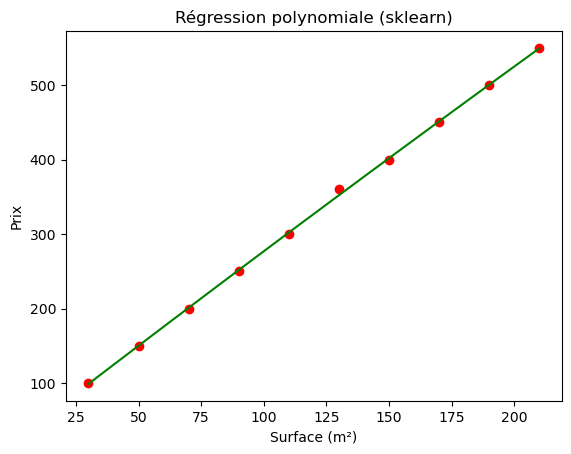

In [13]:
#Régression polynomiale (sklearn)
from sklearn.preprocessing import PolynomialFeatures

 
# ETAPE 1 : Transformation des données

# PolynomialFeatures crée automatiquement x, x², ...

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(surface)

# ETAPE 2 : Entraînement du modèle

modele = LinearRegression()
modele.fit(X_poly, prix)


# ETAPE 3 : Prédictions

X_poly_ligne = poly.transform(surface_ligne)
prix_pred_poly = modele.predict(X_poly_ligne)


# ETAPE 4 : Visualisation

plt.scatter(surface, prix, color='red')
plt.plot(surface_ligne, prix_pred_poly, color='green')
plt.xlabel("Surface (m²)")
plt.ylabel("Prix")
plt.title("Régression polynomiale (sklearn)")
plt.show()